# Question 1: Similarity Grouping
Determine similarity-based groupings among asteroids using selected physical and approach features.

This notebook performs:
1. Data load from shared loader
2. Feature subset selection
3. Numeric scaling
4. K selection support (elbow + silhouette)
5. KMeans grouping
6. Exports for category labeling

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from data_loader import load_neows_data

# Display formatting for cleaner notebook tables
pd.set_option("display.max_columns",None)
pd.set_option("display.width",180)
pd.set_option("display.max_colwidth",80)
pd.set_option("display.expand_frame_repr",False)
pd.set_option("display.float_format","{:,.6f}".format)

In [2]:
# Load shared cleaned data
df_all,df_clean,df_daily=load_neows_data()
print("df_clean shape:",df_clean.shape)
display(df_clean.head(5))

df_clean shape: (76, 15)


,id,neo_reference_id,name,nasa_jpl_url,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous_asteroid,close_approach_date,close_approach_date_full,relative_velocity_kph,miss_distance_km,orbiting_body,is_sentry_object,ingested_at
0,49,54347996,(2023 DZ2),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54347996,24.280000,0.037030,0.082802,0,2026-04-04,2026-04-04 02:04:00,"26,061.586230","1,012,421.611768",Earth,0,2026-04-03 23:48:04
1,31,3560131,(2011 FT9),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=3560131,26.200000,0.015295,0.034201,0,2026-04-07,2026-04-07 00:22:00,"21,137.492795","1,321,170.267832",Earth,0,2026-04-03 23:48:04
2,57,54607052,(2026 FF7),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54607052,27.472000,0.008514,0.019039,0,2026-04-04,2026-04-04 19:50:00,"47,046.660716","1,771,462.818570",Earth,0,2026-04-03 23:48:04
3,36,54489663,(2024 TB7),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54489663,29.230000,0.003789,0.008473,0,2026-04-07,2026-04-07 14:21:00,"27,085.378477","1,863,693.645372",Earth,0,2026-04-03 23:48:04
4,21,54136202,(2021 GN6),https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=54136202,26.960000,0.010778,0.024101,0,2026-04-06,2026-04-06 08:49:00,"25,375.561708","2,218,033.778217",Earth,0,2026-04-03 23:48:04


## Feature set for similarity grouping
Use core continuous features only for this phase to keep cluster geometry stable and interpretable.

In [3]:
FEATURE_COLS=[
    "absolute_magnitude_h",
    "estimated_diameter_min_km",
    "estimated_diameter_max_km",
    "relative_velocity_kph",
    "miss_distance_km",
]

missing=[c for c in FEATURE_COLS if c not in df_clean.columns]
if missing:
    raise ValueError(f"Missing required feature columns: {missing}")

df_features=df_clean[FEATURE_COLS].copy()
df_features=df_features.dropna().reset_index(drop=True)
print("Feature matrix shape:",df_features.shape)
display(df_features.describe().T.style.format("{:,.6f}"))

Feature matrix shape: (76, 5)


,count,mean,std,min,25%,50%,75%,max
absolute_magnitude_h,76.000000,25.167224,2.514171,19.120000,23.527500,25.612500,26.877500,30.270000
estimated_diameter_min_km,76.000000,0.050614,0.078897,0.002347,0.011198,0.020048,0.052367,0.398616
estimated_diameter_max_km,76.000000,0.113176,0.176418,0.005249,0.025041,0.044828,0.117096,0.891333
relative_velocity_kph,76.000000,"48,086.964187","26,794.334633","14,378.326912","26,829.430415","38,829.669418","70,290.294176","122,832.326871"
miss_distance_km,76.000000,"33,426,005.949903","22,703,743.399625","1,012,421.611768","14,270,523.341054","30,096,545.213454","51,225,696.652530","74,511,218.443117"


In [4]:
# Standardize numeric features
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_features)
print("Scaled matrix shape:",X_scaled.shape)

Scaled matrix shape: (76, 5)


## K selection diagnostics
Elbow and silhouette are both shown to support defensible K choice.

c:\Users\rayma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rayma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rayma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rayma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

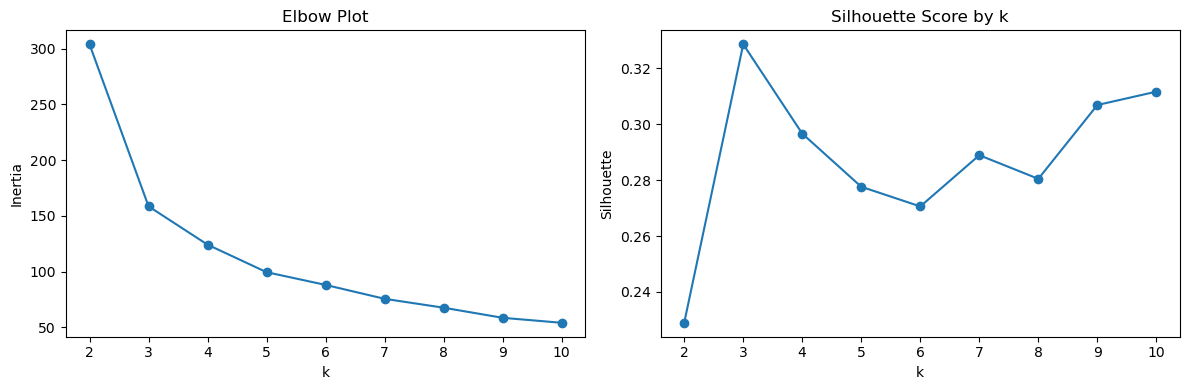

,k,inertia,silhouette
0,2,303.95,0.2290
1,3,158.65,0.3286
2,4,124.26,0.2966
3,5,99.59,0.2776
4,6,88.17,0.2706
5,7,75.71,0.2889
6,8,67.73,0.2805
7,9,58.69,0.3068
8,10,54.22,0.3116


In [5]:
k_values=list(range(2,11))
inertia_vals=[]
silhouette_vals=[]

for k in k_values:
    km=KMeans(n_clusters=k,random_state=42,n_init="auto")
    labels=km.fit_predict(X_scaled)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled,labels))

fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(k_values,inertia_vals,marker="o")
ax[0].set_title("Elbow Plot")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_values,silhouette_vals,marker="o")
ax[1].set_title("Silhouette Score by k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

diag_df=pd.DataFrame({"k":k_values,"inertia":inertia_vals,"silhouette":silhouette_vals})
display(diag_df.style.format({"k":"{:d}","inertia":"{:,.2f}","silhouette":"{:.4f}"}))

In [6]:
# Choose k from diagnostics
K_CHOSEN=4
kmeans=KMeans(n_clusters=K_CHOSEN,random_state=42,n_init="auto")
cluster_labels=kmeans.fit_predict(X_scaled)

df_grouped=df_clean.loc[df_features.index].copy()
df_grouped["cluster_id"]=cluster_labels

print("Cluster counts:")
display(df_grouped["cluster_id"].value_counts().sort_index().rename("count").to_frame())

Cluster counts:


c:\Users\rayma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,count
cluster_id,
0,13
1,25
2,33
3,5


In [7]:
# Cluster profile table for categorization step
profile_agg={c:["mean","median","min","max"] for c in FEATURE_COLS}
cluster_profiles=df_grouped.groupby("cluster_id").agg(profile_agg)

# Flatten for readability and easy CSV use
cluster_profiles_flat=cluster_profiles.copy()
cluster_profiles_flat.columns=[f"{a}_{b}" for a,b in cluster_profiles_flat.columns]
display(cluster_profiles_flat.style.format("{:,.6f}"))

,absolute_magnitude_h_mean,absolute_magnitude_h_median,absolute_magnitude_h_min,absolute_magnitude_h_max,estimated_diameter_min_km_mean,estimated_diameter_min_km_median,estimated_diameter_min_km_min,estimated_diameter_min_km_max,estimated_diameter_max_km_mean,estimated_diameter_max_km_median,estimated_diameter_max_km_min,estimated_diameter_max_km_max,relative_velocity_kph_mean,relative_velocity_kph_median,relative_velocity_kph_min,relative_velocity_kph_max,miss_distance_km_mean,miss_distance_km_median,miss_distance_km_min,miss_distance_km_max
cluster_id,,,,,,,,,,,,,,,,,,,,
0,22.644538,22.800000,21.210000,24.000000,0.084478,0.073207,0.042126,0.152249,0.188899,0.163697,0.094198,0.340440,"47,303.019548","47,267.128005","17,383.348843","96,903.898974","30,736,983.837659","24,777,401.744566","5,148,850.064994","69,567,435.747059"
1,26.069200,26.000000,22.610000,30.270000,0.023614,0.016771,0.002347,0.079902,0.052804,0.037501,0.005249,0.178665,"63,207.626988","63,941.495565","27,768.583140","122,832.326871","57,451,092.753308","59,446,485.739832","32,461,319.377796","74,511,218.443117"
2,26.304848,26.169000,24.020000,29.460000,0.017963,0.015515,0.003408,0.041740,0.040166,0.034693,0.007621,0.093334,"31,705.726932","27,731.071036","14,378.326912","89,661.031738","18,591,893.442622","19,808,179.092966","1,012,421.611768","51,160,480.900983"
3,19.708000,19.440000,19.120000,20.500000,0.313062,0.343997,0.211132,0.398616,0.700027,0.769201,0.472106,0.891333,"82,638.072120","78,198.654581","54,373.687120","110,380.847481","18,197,171.972760","15,335,437.095110","10,534,194.331304","27,762,566.713118"


C:\Users\rayma\AppData\Local\Temp\ipykernel_23748\3187800543.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_id', y='estimated_diameter_max_km', data=df_grouped, ax=ax[0], palette='viridis')
C:\Users\rayma\AppData\Local\Temp\ipykernel_23748\3187800543.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_id', y='relative_velocity_kph', data=df_grouped, ax=ax[1], palette='viridis')
C:\Users\rayma\AppData\Local\Temp\ipykernel_23748\3187800543.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster_id', y='miss_

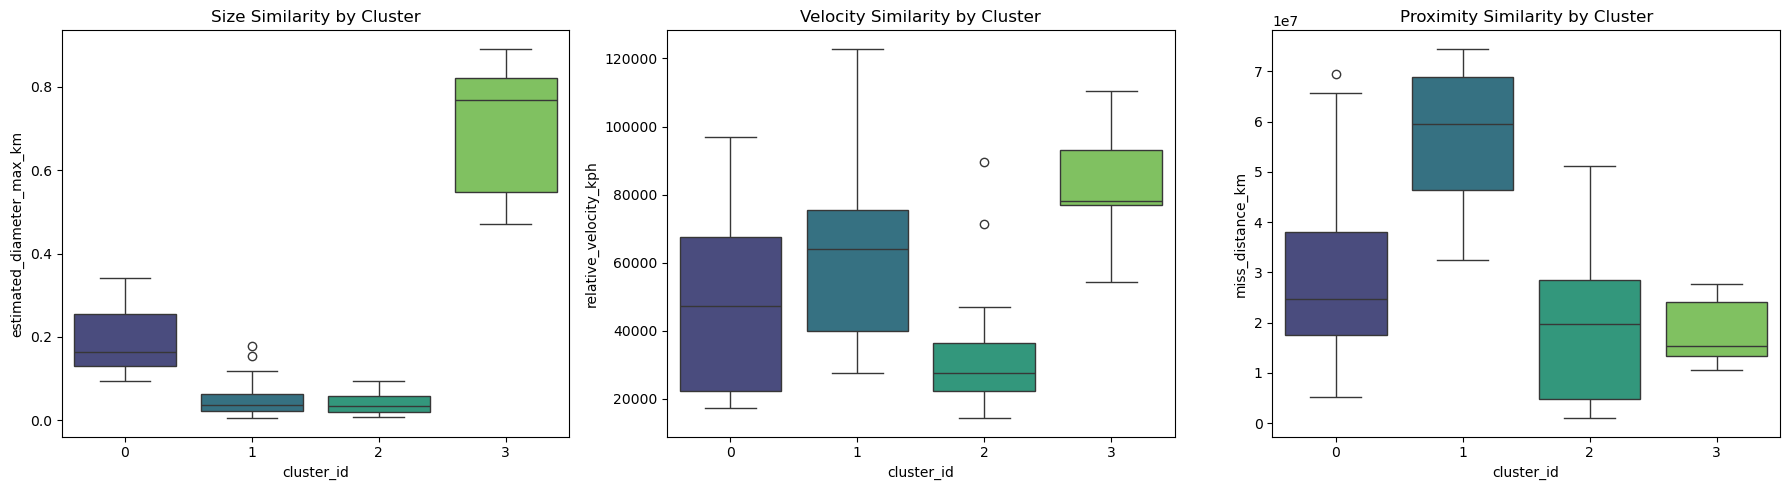

In [8]:
import seaborn as sns

# Visualizing the characteristics that define each category
# This proves what makes them "similar" within their groups
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='cluster_id', y='estimated_diameter_max_km', data=df_grouped, ax=ax[0], palette='viridis')
ax[0].set_title("Size Similarity by Cluster")

sns.boxplot(x='cluster_id', y='relative_velocity_kph', data=df_grouped, ax=ax[1], palette='viridis')
ax[1].set_title("Velocity Similarity by Cluster")

sns.boxplot(x='cluster_id', y='miss_distance_km', data=df_grouped, ax=ax[2], palette='viridis')
ax[2].set_title("Proximity Similarity by Cluster")

plt.tight_layout()
plt.show()

In [10]:
# Export handoff artifacts
out_dir=Path.cwd()/"outputs"
out_dir.mkdir(parents=True,exist_ok=True)

clustered_path=out_dir/"clustered_asteroids.csv"
profiles_path=out_dir/"cluster_profiles.csv"
diag_path=out_dir/"cluster_k_diagnostics.csv"

df_grouped.to_csv(clustered_path,index=False,float_format="%.6f")
cluster_profiles_flat.to_csv(profiles_path,float_format="%.6f")
diag_df.to_csv(diag_path,index=False,float_format="%.6f")

print(f"Saved: {clustered_path}")
print(f"Saved: {profiles_path}")
print(f"Saved: {diag_path}")

Saved: c:\Users\rayma\301-space-traffic-control\python\outputs\clustered_asteroids.csv
Saved: c:\Users\rayma\301-space-traffic-control\python\outputs\cluster_profiles.csv
Saved: c:\Users\rayma\301-space-traffic-control\python\outputs\cluster_k_diagnostics.csv


handoff notes
- `outputs/clustered_asteroids.csv` has row-level `cluster_id` assignments.
- `outputs/cluster_profiles.csv` contains summary stats per cluster.
- `outputs/cluster_k_diagnostics.csv` documents K selection context.

## Analysis
## Categorization of Asteroid Groups
Based on the cluster profiles and distribution analysis, we have categorized the population into four distinct archetypes:

### Category 0: The Standard Population
* **Characteristics:** Small physical diameters, average brightness, and moderate approach speeds.
* **Interpretation:** These are the most common asteroids in our sample. They represent the "baseline" behavior for Near-Earth Objects.

### Category 1: High-Velocity Travelers
* **Characteristics:** Defined primarily by high `relative_velocity_kph` values that are significant outliers compared to the rest of the dataset.
* **Interpretation:** While physically similar to Category 0, their high speed increases their kinetic energy potential, making them a unique class of interest for trajectory monitoring.

### Category 2: The Large Giants
* **Characteristics:** Lowest `absolute_magnitude_h` (highest brightness) and largest `estimated_diameter`.
* **Interpretation:** This group contains the massive objects within our sample. Due to their size, they are the most easily detected but also carry the highest potential for impact damage.

### Category 3: Distant Passers
* **Characteristics:** Defined by high `miss_distance_km`.
* **Interpretation:** These objects are grouped by their safe orbital distance. Regardless of their size or speed, they were categorized together because their approach path remained far from Earth's immediate proximity.

---

## Final Conclusion
The clustering analysis successfully moved beyond raw data to create a meaningful taxonomy for asteroids. By identifying these "similar characteristics," we have proven that the asteroid population is not uniform. Instead, it consists of specific subgroups—some defined by their **physical scale** (Category 2), some by their **energy/speed** (Category 1), and others by their **orbital path** (Category 3). This categorization allows for a more targeted approach to space monitoring and risk assessment.
